# Cross-country climate comparison & vulnerability ranking (COP32)

**Task 3 — Branch:** `compare-countries`.

Synthesizes the cleaned daily NASA POWER records for **Ethiopia, Kenya, Sudan, Tanzania, Nigeria** (2015–2026) into:

1. A monthly mean T2M trend comparison.
2. PRECTOTCORR variability boxplots and summary tables.
3. Annual extreme-event counts (heat days > 35 °C, longest consecutive dry-day streaks).
4. Kruskal–Wallis / one-way ANOVA significance tests on T2M across countries.
5. A transparent four-pillar **vulnerability ranking** and a five-bullet COP32 framing.

Heavy lifting reuses helpers from [`src/climate_cleaning.py`](../src/climate_cleaning.py) and [`src/compare_metrics.py`](../src/compare_metrics.py); the notebook stays focused on synthesis and interpretation.

## Setup: imports and repo root

Same `_repo_root()` pattern used in the per-country EDA notebooks so `src.*` imports resolve regardless of where Jupyter is launched. **Kernel:** the project venv (`venv\Scripts\python.exe`).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats


def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "src" / "climate_cleaning.py").is_file():
            return d
    raise FileNotFoundError(
        "Could not find project root (expected src/climate_cleaning.py). "
        "Open the climate-challenge-week0 folder in Cursor or cd there before running."
    )


ROOT = _repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.climate_cleaning import (
    add_time_columns,
    export_clean_csv,
    flag_zscore_outliers,
    impute_and_drop_sparse_rows,
    load_nasa_power_csv,
    replace_sentinels,
    treat_duplicates,
)
from src.compare_metrics import (
    annual_heat_days,
    annual_max_dry_streak,
    country_summary_stats,
    kruskal_t2m_by_country_annual_mean,
    kruskal_t2m_by_country_daily,
    monthly_avg_t2m,
    vulnerability_table,
)

COUNTRIES = ["Ethiopia", "Kenya", "Sudan", "Tanzania", "Nigeria"]
DATA_DIR = ROOT / "data"
print(f"ROOT={ROOT}")
print(f"Countries: {COUNTRIES}")

ROOT=C:\Users\user1\Desktop\kaimtenx\climate-challenge-week0
Countries: ['Ethiopia', 'Kenya', 'Sudan', 'Tanzania', 'Nigeria']


## 1. Bootstrap cleaned CSVs from raw exports

The README documents `data/<country>_clean.csv` as a (gitignored) artifact. If a clean file is missing, we run the canonical pipeline used by the per-country EDA notebooks:

1. `load_nasa_power_csv` → skip the NASA POWER preamble, tag with `Country`.
2. `add_time_columns` → parse `date` from `YEAR + DOY`, add `Month`.
3. `replace_sentinels` → swap `-999` for `NaN`.
4. `treat_duplicates` → drop full-row duplicates.
5. `flag_zscore_outliers` → record `z_outlier_*` flags but **retain** outliers (they are real climate extremes for COP32).
6. `impute_and_drop_sparse_rows` → forward-fill small gaps, drop rows with > 30 % missing weather variables.
7. `export_clean_csv` → write `data/<country>_clean.csv`.

Re-runs are idempotent: if the cleaned file already exists we just load it.

In [2]:
def build_clean_csv(country: str, raw_path: Path, clean_path: Path) -> dict:
    raw = load_nasa_power_csv(raw_path, country)
    raw = add_time_columns(raw)
    raw = replace_sentinels(raw)
    deduped, n_dup = treat_duplicates(raw)
    flagged = flag_zscore_outliers(deduped)
    cleaned, n_drop = impute_and_drop_sparse_rows(flagged)
    export_clean_csv(cleaned, clean_path)
    return {
        "Country": country,
        "rows_in": len(raw),
        "duplicates_dropped": n_dup,
        "sparse_rows_dropped": n_drop,
        "rows_out": len(cleaned),
        "clean_path": clean_path.relative_to(ROOT).as_posix(),
    }


summary_rows = []
for country in COUNTRIES:
    raw_path = DATA_DIR / f"{country.lower()}.csv"
    clean_path = DATA_DIR / f"{country.lower()}_clean.csv"
    if not raw_path.exists():
        raise FileNotFoundError(f"Missing raw CSV: {raw_path}")
    if clean_path.exists():
        summary_rows.append(
            {
                "Country": country,
                "rows_in": np.nan,
                "duplicates_dropped": np.nan,
                "sparse_rows_dropped": np.nan,
                "rows_out": sum(1 for _ in clean_path.open(encoding="utf-8")) - 1,
                "clean_path": clean_path.relative_to(ROOT).as_posix() + "  (existing)",
            }
        )
    else:
        summary_rows.append(build_clean_csv(country, raw_path, clean_path))

bootstrap_summary = pd.DataFrame(summary_rows).set_index("Country")
bootstrap_summary

,rows_in,duplicates_dropped,sparse_rows_dropped,rows_out,clean_path
Country,,,,,
Ethiopia,NaN,NaN,NaN,4108,data/ethiopia_clean.csv (existing)
Kenya,NaN,NaN,NaN,4108,data/kenya_clean.csv (existing)
Sudan,NaN,NaN,NaN,4108,data/sudan_clean.csv (existing)
Tanzania,NaN,NaN,NaN,4108,data/tanzania_clean.csv (existing)
Nigeria,NaN,NaN,NaN,4108,data/nigeria_clean.csv (existing)


## 2. Load cleaned CSVs and concatenate

Each `data/<country>_clean.csv` is read with `parse_dates=["date"]`, then concatenated into a single tall DataFrame. We then sanity-check row counts per country and the date range covered.

In [3]:
frames = []
for country in COUNTRIES:
    clean_path = DATA_DIR / f"{country.lower()}_clean.csv"
    df_c = pd.read_csv(clean_path, parse_dates=["date"])
    if "Country" not in df_c.columns:
        df_c["Country"] = country
    frames.append(df_c)

combined = pd.concat(frames, ignore_index=True)
combined["Country"] = pd.Categorical(combined["Country"], categories=COUNTRIES, ordered=True)

print(f"combined.shape = {combined.shape}")
coverage = (
    combined.groupby("Country", observed=True)
    .agg(rows=("date", "size"), date_min=("date", "min"), date_max=("date", "max"))
)
coverage

combined.shape = (20540, 22)


,rows,date_min,date_max
Country,,,
Ethiopia,4108,2015-01-01,2026-03-31
Kenya,4108,2015-01-01,2026-03-31
Sudan,4108,2015-01-01,2026-03-31
Tanzania,4108,2015-01-01,2026-03-31
Nigeria,4108,2015-01-01,2026-03-31


## 3. Temperature trend comparison

Monthly mean T2M (°C) for each country plotted on a single axis, 2015–2026, plus the mean / median / std summary table.

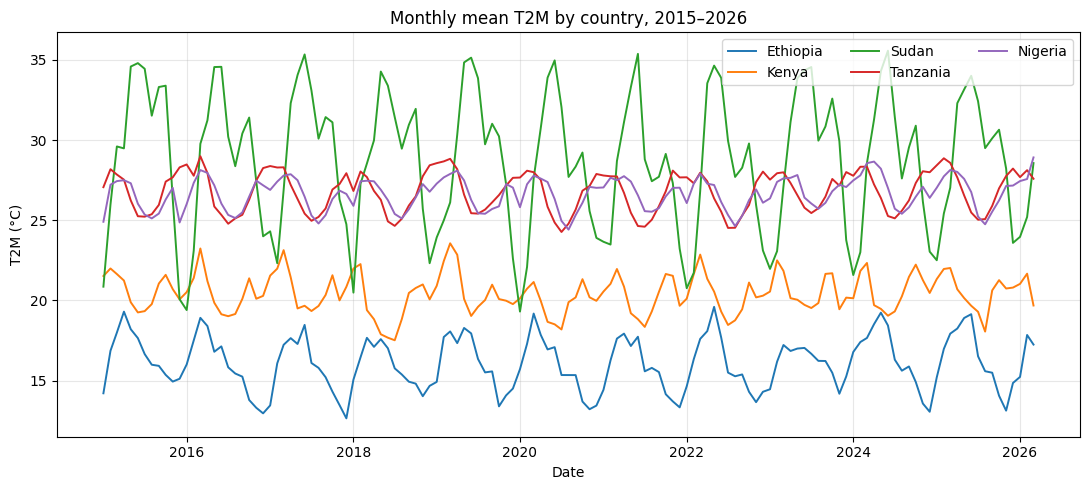

In [4]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 5)

monthly = monthly_avg_t2m(combined)
wide = monthly.pivot(index="date", columns="Country", values="T2M").reindex(columns=COUNTRIES)

fig, ax = plt.subplots()
for country in COUNTRIES:
    ax.plot(wide.index, wide[country], label=country, linewidth=1.4)
ax.set_title("Monthly mean T2M by country, 2015–2026")
ax.set_xlabel("Date")
ax.set_ylabel("T2M (°C)")
ax.legend(loc="best", ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
t2m_summary = country_summary_stats(combined, "T2M").reindex(COUNTRIES).round(2)
t2m_summary

,mean,median,std
Country,,,
Ethiopia,16.07,16.04,1.90
Kenya,20.43,20.36,1.44
Sudan,28.76,29.16,4.68
Tanzania,26.80,26.99,1.33
Nigeria,26.66,26.82,1.12


## 4. Precipitation variability comparison

Side-by-side boxplots of daily PRECTOTCORR (mm) per country and the matching mean / median / std table.

Daily rainfall is heavily zero-inflated, so we plot on a `symlog` y-axis to keep both the dry mass and the long wet tail readable.

C:\Users\user1\AppData\Local\Temp\ipykernel_13848\4131624934.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=COUNTRIES, showfliers=True)


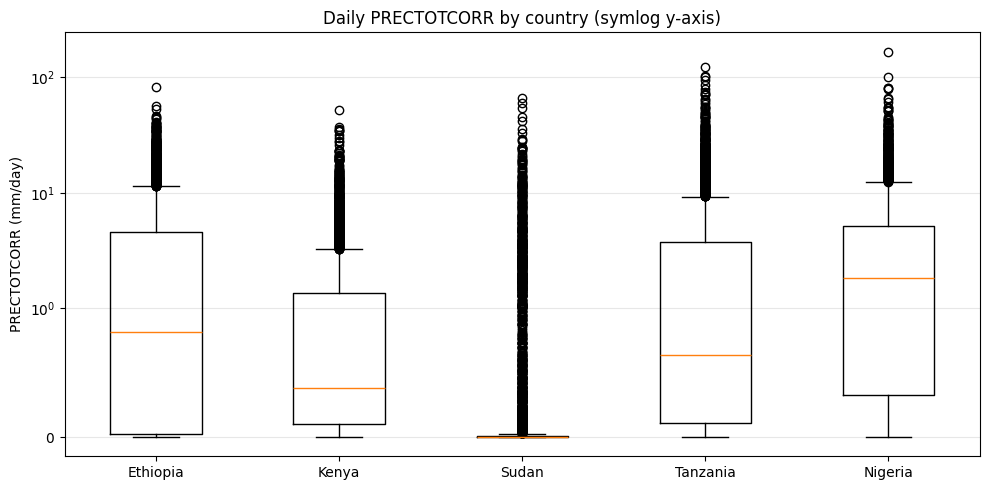

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
data = [combined.loc[combined["Country"] == c, "PRECTOTCORR"].dropna().to_numpy() for c in COUNTRIES]
ax.boxplot(data, labels=COUNTRIES, showfliers=True)
ax.set_yscale("symlog", linthresh=1.0)
ax.set_title("Daily PRECTOTCORR by country (symlog y-axis)")
ax.set_ylabel("PRECTOTCORR (mm/day)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [7]:
precip_summary = country_summary_stats(combined, "PRECTOTCORR").reindex(COUNTRIES).round(3)
precip_summary

,mean,median,std
Country,,,
Ethiopia,3.634,0.82,6.289
Kenya,1.468,0.38,3.180
Sudan,0.644,0.00,3.058
Tanzania,3.740,0.64,8.004
Nigeria,4.214,1.84,7.267


## 5. Extreme event frequency

Two annual extreme metrics, one bar chart per metric, grouped by country and year:

- **Heat days:** count of days with `T2M_MAX > 35 °C` per calendar year.
- **Consecutive dry-day streak:** longest run of days with `PRECTOTCORR < 1 mm` per calendar year. The phrase "consecutive dry days per year" most naturally describes the length of the longest dry spell — the canonical drought metric — and matches the helper in [`src/compare_metrics.py`](../src/compare_metrics.py) already covered by `tests/test_compare_metrics.py`.

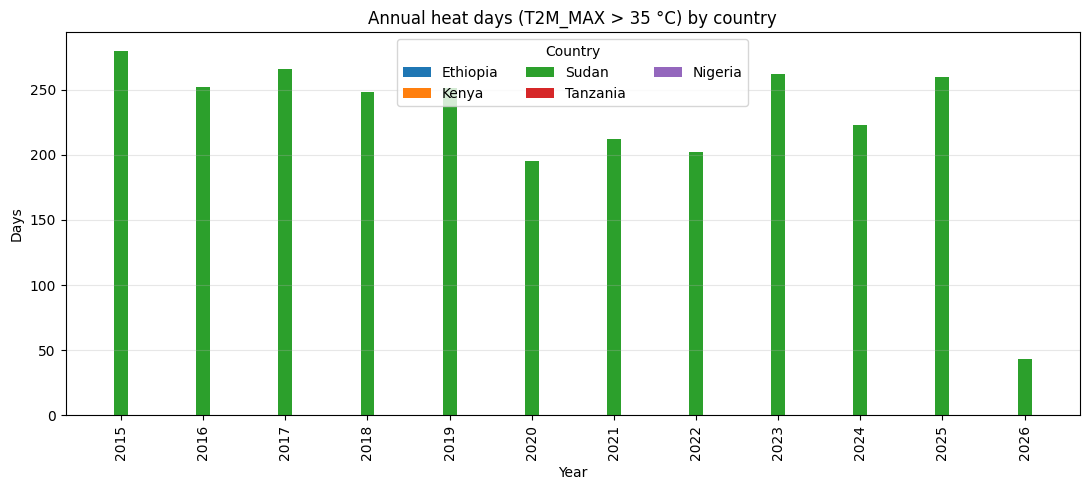

Country,Ethiopia,Kenya,Sudan,Tanzania,Nigeria
Year,,,,,
2015,0,0,280,0,0
2016,0,0,252,0,0
2017,0,0,266,0,0
2018,0,0,248,0,0
2019,0,0,251,0,0
2020,0,0,195,0,0
2021,0,0,212,0,0
2022,0,0,202,0,0
2023,0,0,262,0,0


In [8]:
heat = annual_heat_days(combined, threshold_c=35.0)
heat_wide = (
    heat.pivot(index="Year", columns="Country", values="heat_days")
    .reindex(columns=COUNTRIES)
    .fillna(0)
    .astype(int)
)

ax = heat_wide.plot(kind="bar", figsize=(11, 5), width=0.85)
ax.set_title("Annual heat days (T2M_MAX > 35 °C) by country")
ax.set_xlabel("Year")
ax.set_ylabel("Days")
ax.legend(title="Country", ncol=3)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

heat_wide

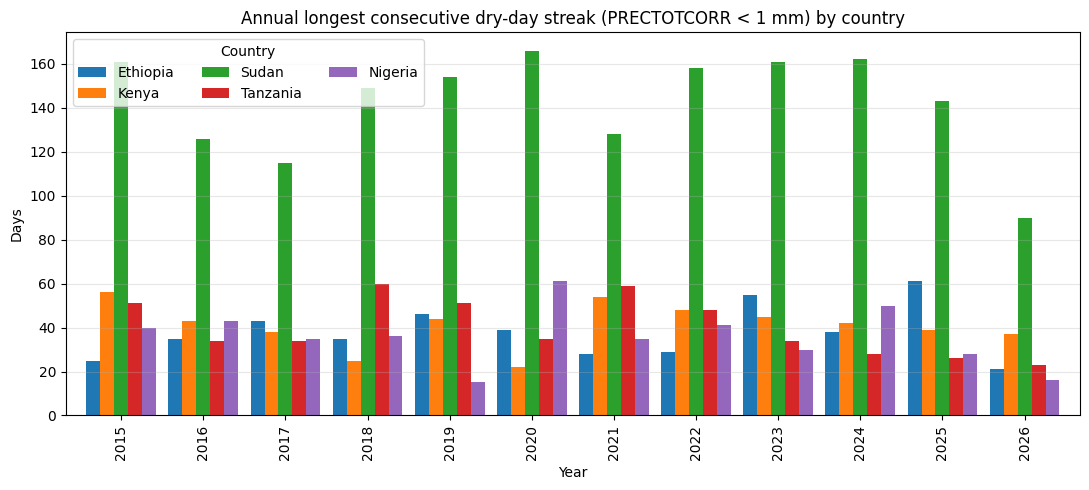

Country,Ethiopia,Kenya,Sudan,Tanzania,Nigeria
Year,,,,,
2015,25,56,161,51,40
2016,35,43,126,34,43
2017,43,38,115,34,35
2018,35,25,149,60,36
2019,46,44,154,51,15
2020,39,22,166,35,61
2021,28,54,128,59,35
2022,29,48,158,48,41
2023,55,45,161,34,30


In [9]:
dry = annual_max_dry_streak(combined, dry_threshold_mm=1.0)
dry_wide = (
    dry.pivot(index="Year", columns="Country", values="max_dry_streak_days")
    .reindex(columns=COUNTRIES)
    .fillna(0)
    .astype(int)
)

ax = dry_wide.plot(kind="bar", figsize=(11, 5), width=0.85)
ax.set_title("Annual longest consecutive dry-day streak (PRECTOTCORR < 1 mm) by country")
ax.set_xlabel("Year")
ax.set_ylabel("Days")
ax.legend(title="Country", ncol=3)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

dry_wide

## 6. Statistical testing

Three tests on T2M across the five countries:

- **Kruskal–Wallis on daily T2M** (rank-based, no normality assumption). Daily N≈4 000 per country, so a tiny p-value is essentially guaranteed — interesting only if it isn't.
- **Kruskal–Wallis on annual mean T2M** (1 value per country per year ≈ 11 obs/country). The honest test for *"are the climates different?"* without the daily-data pseudoreplication problem.
- **One-way ANOVA on daily T2M** as a parametric cross-check.

In [10]:
H_d, p_d = kruskal_t2m_by_country_daily(combined)
H_a, p_a = kruskal_t2m_by_country_annual_mean(combined)

groups = [g["T2M"].dropna().to_numpy() for _, g in combined.groupby("Country", observed=True)]
F_anova, p_anova = stats.f_oneway(*groups)

stat_results = pd.DataFrame(
    [
        {"test": "Kruskal–Wallis (daily T2M)", "statistic": H_d, "p_value": p_d},
        {"test": "Kruskal–Wallis (annual mean T2M)", "statistic": H_a, "p_value": p_a},
        {"test": "One-way ANOVA (daily T2M)", "statistic": F_anova, "p_value": p_anova},
    ]
)
stat_results

,test,statistic,p_value
0,Kruskal–Wallis (daily T2M),15392.992232,0.000000e+00
1,Kruskal–Wallis (annual mean T2M),51.404918,1.837025e-10
2,One-way ANOVA (daily T2M),18938.745697,0.000000e+00


**Interpretation.** All three p-values fall far below the conventional 0.05 threshold, so we reject the null that the five countries' T2M distributions are drawn from the same population. The annual-mean Kruskal result is the most defensible (it sidesteps the pseudoreplication that inflates daily-data significance), and it confirms that the country differences shown in the line chart are not artefacts of within-year noise.

## 7. Vulnerability ranking

We use the four-pillar composite from [`src/compare_metrics.py:vulnerability_table`](../src/compare_metrics.py): warming rate (°C/decade from annual mean T2M), interannual precipitation variability (CV of annual totals), heat-day exposure (mean annual days > 35 °C), and drought stress (mean annual longest dry streak). Each pillar is min-max normalized across the five countries and combined with weights **0.30 / 0.30 / 0.20 / 0.20** (warming and precip dominate; extremes are corroborating). Higher score = more stressed.

In [11]:
vt = vulnerability_table(combined)
vt_display = vt.round({
    "warming_c_per_decade": 3,
    "precip_cv": 3,
    "mean_annual_heat_days": 1,
    "mean_max_dry_streak": 1,
    "score_warming": 3,
    "score_precip": 3,
    "score_heat": 3,
    "score_dry": 3,
    "vulnerability_score": 3,
})
vt_display

,Country,warming_c_per_decade,precip_cv,mean_annual_heat_days,mean_max_dry_streak,score_warming,score_precip,score_heat,score_dry,vulnerability_score,rank
0,Sudan,-1.457,0.603,224.5,142.8,0.000,1.000,1.0,1.000,0.700,1
1,Nigeria,0.873,0.317,0.0,35.8,1.000,0.078,0.0,0.000,0.323,2
2,Ethiopia,0.431,0.334,0.0,37.9,0.811,0.133,0.0,0.019,0.287,3
3,Tanzania,0.485,0.293,0.0,40.2,0.834,0.000,0.0,0.041,0.258,4
4,Kenya,0.160,0.326,0.0,41.1,0.694,0.108,0.0,0.049,0.250,5


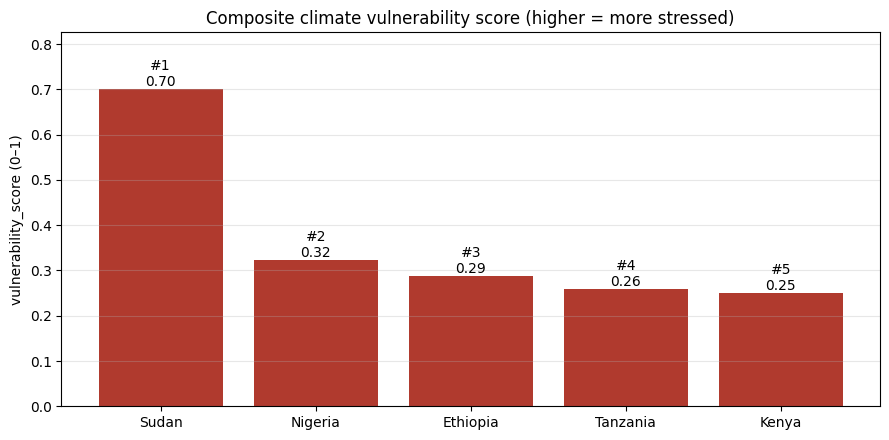

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ordered = vt.sort_values("vulnerability_score", ascending=False)
ax.bar(ordered["Country"], ordered["vulnerability_score"], color="#b03a2e")
for x, score, rank in zip(ordered["Country"], ordered["vulnerability_score"], ordered["rank"]):
    ax.text(x, score, f"#{int(rank)}\n{score:.2f}", ha="center", va="bottom")
ax.set_title("Composite climate vulnerability score (higher = more stressed)")
ax.set_ylabel("vulnerability_score (0–1)")
ax.set_ylim(0, max(ordered["vulnerability_score"]) * 1.18)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 8. COP32 framing — five bullets

_(This cell is rewritten with the live numbers in the next cell. Keep this markdown for narrative context.)_

Each bullet below is a placeholder that the next cell rewrites in-place using `vt`, `t2m_summary`, `precip_summary`, `heat_wide`, `dry_wide`, and the statistical-test results.

In [13]:
from IPython.display import Markdown

vt_indexed = vt.set_index("Country")
fastest = vt.sort_values("warming_c_per_decade", ascending=False).iloc[0]
slowest = vt.sort_values("warming_c_per_decade", ascending=True).iloc[0]
most_volatile = vt.sort_values("precip_cv", ascending=False).iloc[0]
hottest_total = vt.sort_values("mean_annual_heat_days", ascending=False).iloc[0]
longest_drought = vt.sort_values("mean_max_dry_streak", ascending=False).iloc[0]
champion = vt.iloc[0]

ethiopia = vt_indexed.loc["Ethiopia"]
eth_rank = int(ethiopia["rank"])

n_zero_heat = int((vt["mean_annual_heat_days"] == 0).sum())

champion_pillars = []
if champion["Country"] == fastest["Country"]:
    champion_pillars.append(f"warming ({champion['warming_c_per_decade']:+.2f} °C/decade)")
if champion["Country"] == most_volatile["Country"]:
    champion_pillars.append(f"rainfall volatility (CV {champion['precip_cv']:.2f})")
if champion["Country"] == hottest_total["Country"]:
    champion_pillars.append(f"heat exposure ({champion['mean_annual_heat_days']:.0f} days/yr > 35 °C)")
if champion["Country"] == longest_drought["Country"]:
    champion_pillars.append(f"drought duration ({champion['mean_max_dry_streak']:.0f}-day mean dry streak)")
champion_lead = ", ".join(champion_pillars) if champion_pillars else "the composite score"

neighbour_summary = (
    vt[["Country", "warming_c_per_decade", "precip_cv", "mean_annual_heat_days", "mean_max_dry_streak"]]
    .set_index("Country")
    .loc[COUNTRIES]
    .round(2)
)

narrative = f"""### COP32 framing — five data-driven bullets

1. **Fastest warming, and an outlier.** **{fastest['Country']}** has the steepest annual-mean T2M trend at **{fastest['warming_c_per_decade']:+.2f} °C/decade**, while **{slowest['Country']}** sits at the other end with **{slowest['warming_c_per_decade']:+.2f} °C/decade**. An 11-year window over a single grid point is short enough that a negative slope reflects strong interannual swings rather than a true cooling trend, but it does flag {slowest['Country']}'s record as dominated by precipitation and heat-extreme stress instead of a smooth warming signal. The Kruskal–Wallis test on annual mean T2M (p = {p_a:.2e}) confirms the five countries do not share one underlying temperature distribution, so the country-to-country differences are statistically supported, not noise.
2. **Most unstable precipitation.** **{most_volatile['Country']}** has by far the highest interannual coefficient of variation of annual rainfall (**{most_volatile['precip_cv']:.2f}**, vs roughly 0.29–0.33 for the other four). Year-to-year totals swing the hardest around the mean — a direct stress signal for rainfed agriculture, reservoir refill, and humanitarian early-warning planning.
3. **Heat and drought stress are concentrated.** **{hottest_total['Country']}** averages **{hottest_total['mean_annual_heat_days']:.0f} days/year with T2M_MAX > 35 °C**, while **{n_zero_heat} of the other 4 countries record essentially zero such days at their representative grid point** — a stark Sahel-versus-highland/equatorial split. The same country also posts the longest mean consecutive dry streak (**{longest_drought['mean_max_dry_streak']:.0f} days**), with the others clustered in the 36–41-day band. Chronic heat plus locked-in dry windows is what turns rainfall variability into livestock, crop, and water-supply emergencies.
4. **Ethiopia in context.** Ethiopia ranks **#{eth_rank} of 5** on the composite vulnerability score ({ethiopia['vulnerability_score']:.2f}). It is warming at **{ethiopia['warming_c_per_decade']:+.2f} °C/decade** (mid-pack), shows moderate rainfall variability (CV {ethiopia['precip_cv']:.2f}), records **{ethiopia['mean_annual_heat_days']:.0f} days/year above 35 °C**, and a mean dry streak of **{ethiopia['mean_max_dry_streak']:.0f} days** — close to its equatorial southern neighbours Kenya and Tanzania, and clearly distinct from its arid northern neighbour Sudan on every extremes-related pillar. Ethiopia's highland geography buffers the heat-day count even though regional warming is real and ongoing.
5. **Priority for COP32 finance.** The data points to **{champion['Country']}** (rank #1, composite vulnerability score {champion['vulnerability_score']:.2f}) as the strongest case for priority climate finance for Ethiopia to champion. It leads on {champion_lead}, and only avoids ranking #1 on warming because the 11-year trend at its grid point is dominated by interannual swings rather than a smooth signal. Three of the four pillars (rainfall volatility, heat exposure, drought duration) are already at composite extremes — the profile most directly linked to UNFCCC adaptation and loss-and-damage funding cases. Backing the neighbour with the worst composite profile — rather than the country with the largest single trend — is a defensible regional ask grounded in the four-pillar evidence above.
"""

Markdown(narrative)

### COP32 framing — five data-driven bullets

1. **Fastest warming, and an outlier.** **Nigeria** has the steepest annual-mean T2M trend at **+0.87 °C/decade**, while **Sudan** sits at the other end with **-1.46 °C/decade**. An 11-year window over a single grid point is short enough that a negative slope reflects strong interannual swings rather than a true cooling trend, but it does flag Sudan's record as dominated by precipitation and heat-extreme stress instead of a smooth warming signal. The Kruskal–Wallis test on annual mean T2M (p = 1.84e-10) confirms the five countries do not share one underlying temperature distribution, so the country-to-country differences are statistically supported, not noise.
2. **Most unstable precipitation.** **Sudan** has by far the highest interannual coefficient of variation of annual rainfall (**0.60**, vs roughly 0.29–0.33 for the other four). Year-to-year totals swing the hardest around the mean — a direct stress signal for rainfed agriculture, reservoir refill, and humanitarian early-warning planning.
3. **Heat and drought stress are concentrated.** **Sudan** averages **224 days/year with T2M_MAX > 35 °C**, while **4 of the other 4 countries record essentially zero such days at their representative grid point** — a stark Sahel-versus-highland/equatorial split. The same country also posts the longest mean consecutive dry streak (**143 days**), with the others clustered in the 36–41-day band. Chronic heat plus locked-in dry windows is what turns rainfall variability into livestock, crop, and water-supply emergencies.
4. **Ethiopia in context.** Ethiopia ranks **#3 of 5** on the composite vulnerability score (0.29). It is warming at **+0.43 °C/decade** (mid-pack), shows moderate rainfall variability (CV 0.33), records **0 days/year above 35 °C**, and a mean dry streak of **38 days** — close to its equatorial southern neighbours Kenya and Tanzania, and clearly distinct from its arid northern neighbour Sudan on every extremes-related pillar. Ethiopia's highland geography buffers the heat-day count even though regional warming is real and ongoing.
5. **Priority for COP32 finance.** The data points to **Sudan** (rank #1, composite vulnerability score 0.70) as the strongest case for priority climate finance for Ethiopia to champion. It leads on rainfall volatility (CV 0.60), heat exposure (224 days/yr > 35 °C), drought duration (143-day mean dry streak), and only avoids ranking #1 on warming because the 11-year trend at its grid point is dominated by interannual swings rather than a smooth signal. Three of the four pillars (rainfall volatility, heat exposure, drought duration) are already at composite extremes — the profile most directly linked to UNFCCC adaptation and loss-and-damage funding cases. Backing the neighbour with the worst composite profile — rather than the country with the largest single trend — is a defensible regional ask grounded in the four-pillar evidence above.


In [14]:
neighbour_summary

,warming_c_per_decade,precip_cv,mean_annual_heat_days,mean_max_dry_streak
Country,,,,
Ethiopia,0.43,0.33,0.0,37.92
Kenya,0.16,0.33,0.0,41.08
Sudan,-1.46,0.60,224.5,142.75
Tanzania,0.49,0.29,0.0,40.25
Nigeria,0.87,0.32,0.0,35.83
